# Boundary Condition Performance Tests

In [1]:
"""
Benchmark for boundary conditions implementations in Sarkas.

This script compares the performance of Numba-accelerated boundary condition functions
with their pure NumPy counterparts across different system sizes.
"""

import numpy as np
import matplotlib.pyplot as plt
import time
from sarkas.time_evolution.integrators import enforce_pbc, enforce_abc, enforce_rbc
from tqdm import tqdm


# Pure NumPy versions of the boundary condition functions
def enforce_pbc_numpy(pos, cntr, box_lengths):
    """
    NumPy version of periodic boundary conditions.
    """
    fold_count = np.floor(pos / box_lengths).astype(int)
    cntr += fold_count
    pos -= box_lengths * fold_count
    
def enforce_abc_numpy(pos, vel, acc, charges, box_vector):
    """
    NumPy version of absorbing boundary conditions.
    """
    # Create masks for particles outside the box
    outside_pos = (pos >= box_vector) | (pos <= 0.0)
    
    # Apply the conditions where needed
    for d in range(pos.shape[1]):
        # Get particles that are outside in this dimension
        outside_particles = np.where(outside_pos[:, d])[0]
        
        if len(outside_particles) > 0:
            # Reset position to boundary
            pos_mask = pos[outside_particles, d] >= box_vector[d]
            pos[outside_particles[pos_mask], d] = box_vector[d]
            
            neg_mask = pos[outside_particles, d] <= 0.0
            pos[outside_particles[neg_mask], d] = 0.0
            
            # Reset velocity, acceleration, and charge
            vel[outside_particles] = 0.0
            acc[outside_particles] = 0.0
            charges[outside_particles] = 0.0

def enforce_rbc_numpy(pos, vel, box_vector, dt):
    """
    NumPy version of reflecting boundary conditions.
    """
    # Create masks for particles outside the box
    outside_pos = (pos > box_vector) | (pos < 0.0)
    
    # Reverse velocity where needed
    for d in range(pos.shape[1]):
        outside_particles = np.where(outside_pos[:, d])[0]
        if len(outside_particles) > 0:
            # Revert velocity for these particles
            vel[outside_particles, d] *= -1.0
            # Restore previous position assuming verlet algorithm
            pos[outside_particles, d] += vel[outside_particles, d] * dt

def benchmark_functions(N_values):
    """Run benchmarks for all boundary condition functions."""
    # Storage for timing results
    pbc_times_numba = []
    pbc_times_numpy = []
    
    abc_times_numba = []
    abc_times_numpy = []
    
    rbc_times_numba = []
    rbc_times_numpy = []
    
    for N in tqdm(N_values, desc="Benchmarking system sizes"):
        N = int(N)  # Ensure N is an integer
        
        # Generate random data for testing
        pos = np.random.random((N, 3)) * 2.0  # Random positions
        vel = np.random.random((N, 3)) - 0.5  # Random velocities
        acc = np.random.random((N, 3)) - 0.5  # Random accelerations
        charges = np.random.random(N)  # Random charges
        box_lengths = np.array([1.0, 1.0, 1.0])  # Unit box
        dt = 0.01  # Sample timestep
        
        # Create copies for NumPy versions to ensure fair comparison
        pos_numba = pos.copy()
        cntr_numba = np.zeros_like(pos)
        
        pos_numpy = pos.copy()
        cntr_numpy = np.zeros_like(pos)
        
        # === Test PBC ===
        # Time Numba version
        start = time.time()
        enforce_pbc(pos_numba, cntr_numba, box_lengths)
        end = time.time()
        pbc_times_numba.append(end - start)
        
        # Time NumPy version
        start = time.time()
        enforce_pbc_numpy(pos_numpy, cntr_numpy, box_lengths)
        end = time.time()
        pbc_times_numpy.append(end - start)
        
        # === Test ABC ===
        # Reset with new copies
        pos_numba = pos.copy()
        vel_numba = vel.copy()
        acc_numba = acc.copy()
        charges_numba = charges.copy()
        
        pos_numpy = pos.copy()
        vel_numpy = vel.copy()
        acc_numpy = acc.copy()
        charges_numpy = charges.copy()
        
        # Time Numba version
        start = time.time()
        enforce_abc(pos_numba, vel_numba, acc_numba, charges_numba, box_lengths)
        end = time.time()
        abc_times_numba.append(end - start)
        
        # Time NumPy version
        start = time.time()
        enforce_abc_numpy(pos_numpy, vel_numpy, acc_numpy, charges_numpy, box_lengths)
        end = time.time()
        abc_times_numpy.append(end - start)
        
        # === Test RBC ===
        # Reset with new copies
        pos_numba = pos.copy()
        vel_numba = vel.copy()
        
        pos_numpy = pos.copy()
        vel_numpy = vel.copy()
        
        # Time Numba version
        start = time.time()
        enforce_rbc(pos_numba, vel_numba, box_lengths, dt)
        end = time.time()
        rbc_times_numba.append(end - start)
        
        # Time NumPy version
        start = time.time()
        enforce_rbc_numpy(pos_numpy, vel_numpy, box_lengths, dt)
        end = time.time()
        rbc_times_numpy.append(end - start)
    
    return {
        'pbc': {'numba': pbc_times_numba, 'numpy': pbc_times_numpy},
        'abc': {'numba': abc_times_numba, 'numpy': abc_times_numpy},
        'rbc': {'numba': rbc_times_numba, 'numpy': rbc_times_numpy}
    }

def plot_results(N_values, results):
    """Plot timing results and speedup."""
    function_names = ['Periodic Boundary Conditions (PBC)', 
                      'Absorbing Boundary Conditions (ABC)',
                      'Reflecting Boundary Conditions (RBC)']
    function_keys = ['pbc', 'abc', 'rbc']
    
    for name, key in zip(function_names, function_keys):
        # Create 1x2 subplot
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        
        # Plot execution times
        ax[0].loglog(N_values, results[key]['numba'], 'o-', label='Numba')
        ax[0].loglog(N_values, results[key]['numpy'], 's-', label='NumPy')
        ax[0].set_xlabel('Number of Particles (N)')
        ax[0].set_ylabel('Execution Time (s)')
        ax[0].set_title(f'Execution Time: {name}')
        ax[0].legend()
        ax[0].grid(True, which="both", ls="-")
        
        # Calculate and plot speedup
        speedup = np.array(results[key]['numpy']) / np.array(results[key]['numba'])
        ax[1].semilogx(N_values, speedup, 'o-', color='green')
        ax[1].set_xlabel('Number of Particles (N)')
        ax[1].set_ylabel('Speedup Factor (NumPy Time / Numba Time)')
        ax[1].set_title(f'Speedup Factor: {name}')
        ax[1].grid(True)
        
        # Add horizontal line at y=1 for reference
        ax[1].axhline(y=1, color='r', linestyle='--', alpha=0.5)
        
        # Display max speedup value
        max_speedup = np.max(speedup)
        ax[1].text(0.05, 0.95, f'Max Speedup: {max_speedup:.1f}×', 
                  transform=ax[1].transAxes, 
                  bbox=dict(facecolor='white', alpha=0.5))
        
        plt.tight_layout()
        # plt.savefig(f'benchmark_{key}.png', dpi=300)
        # plt.show()

Compiling Numba functions...
Running benchmarks...


Benchmarking system sizes: 100%|██████████| 15/15 [00:00<00:00, 33.40it/s] 


Plotting results...
Done!


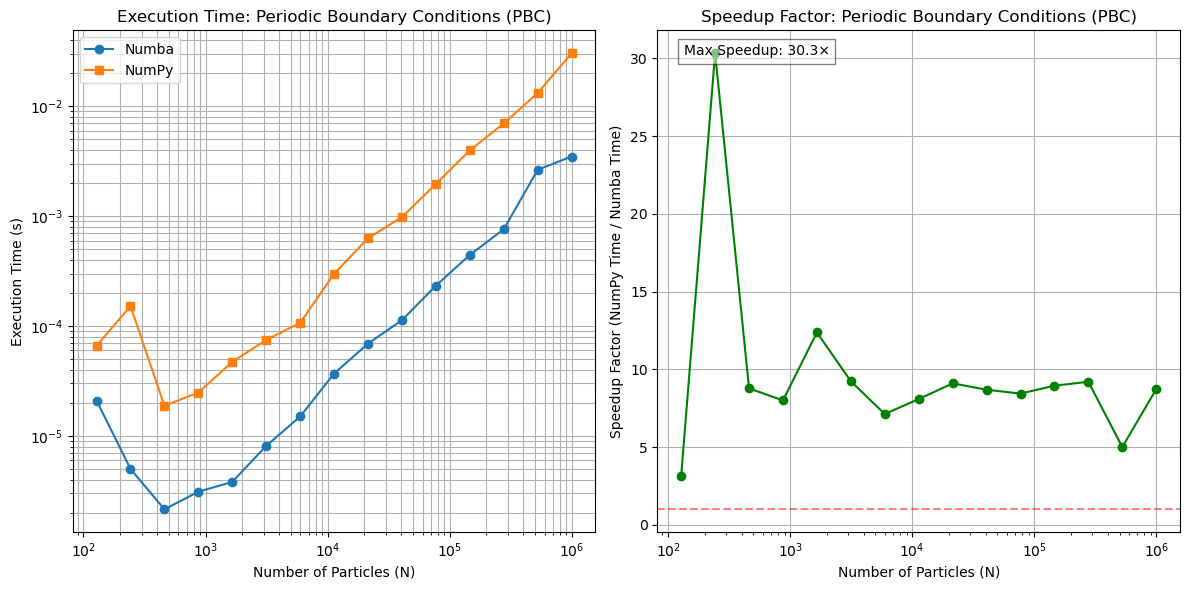

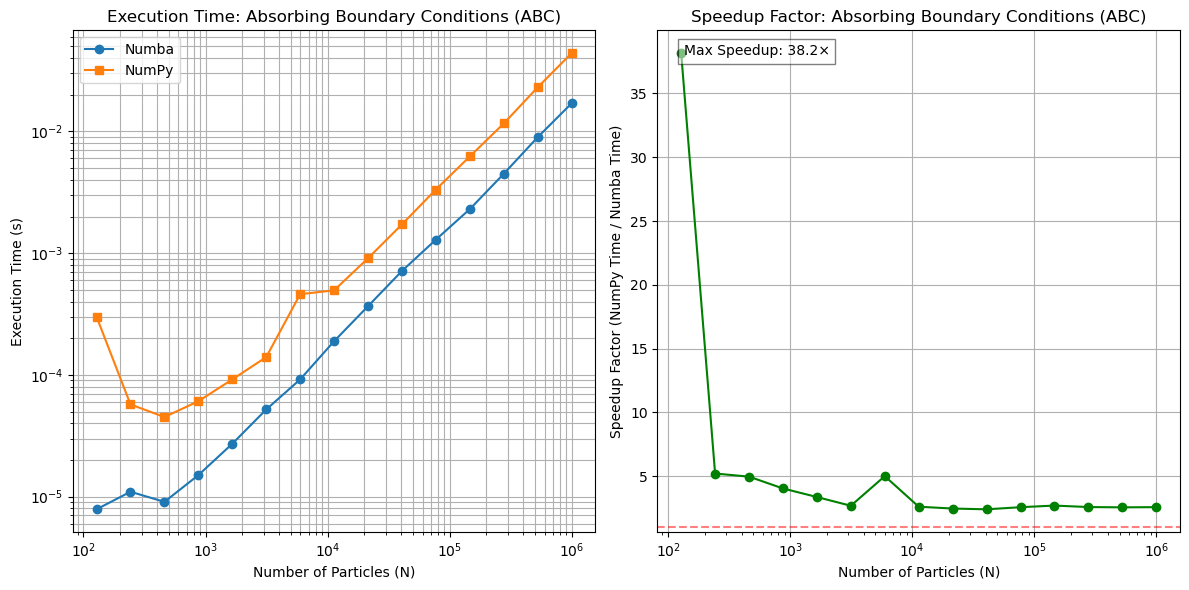

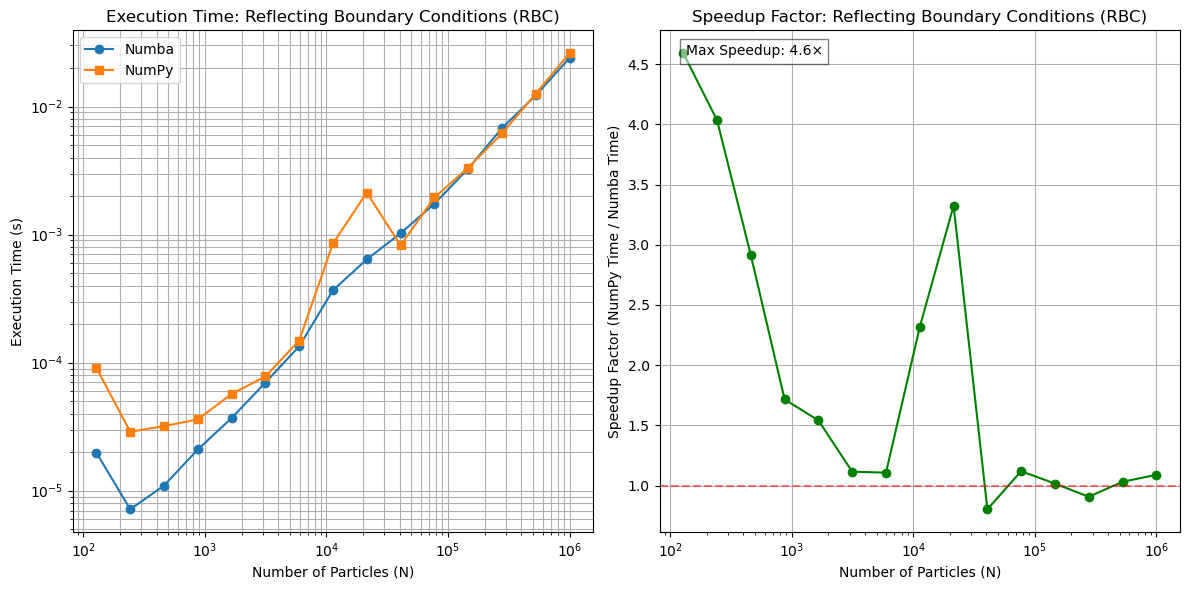

In [2]:
"""Main function to run benchmarks and plot results."""
# Create logarithmically spaced N values from 128 to 10^5
N_values = np.logspace(np.log10(128), np.log10(1e6), num=15)

# Run once for compilation
print("Compiling Numba functions...")
enforce_pbc(np.zeros((1, 3)), np.zeros((1, 3)), np.array([1.0, 1.0, 1.0]))
enforce_abc(np.zeros((1, 3)), np.zeros((1, 3)), np.zeros((1, 3)), np.zeros(1), np.array([1.0, 1.0, 1.0]))
enforce_rbc(np.zeros((1, 3)), np.zeros((1, 3)), np.array([1.0, 1.0, 1.0]), 0.01)

# Run benchmarks
print("Running benchmarks...")
results = benchmark_functions(N_values)

# Plot results
print("Plotting results...")
plot_results(N_values, results)

print("Done!")